# Order Book Imbalance Basics

This notebook is a descriptive research outline for the order book imbalance study inspired by `Enhancing Trading Strategies with Order Book Signals`.

The goal is to first understand whether order book imbalance carries short-horizon information in our data. This notebook should stay readable for both technical and less technical readers: each mathematical object is defined first, then explained in plain language.

This is not a trading strategy notebook. It is a signal diagnostics notebook.

## Reading Guide

The central object is order book imbalance. It compares how much visible volume is available to buy at the best bid versus how much visible volume is available to sell at the best ask.

A positive imbalance means the bid side is heavier than the ask side. A negative imbalance means the ask side is heavier than the bid side. We then ask whether these states help explain market-order arrivals and very short-term midprice changes.

The notebook is organized from basic diagnostics to richer conditional summaries. We start with the imbalance series itself, then study how long the book spends in each state, how states transition, whether market-order intensity changes by state, and whether future price changes differ by state.

In [1]:
# Notebook parameters. These values are intentionally simple defaults.

SYMBOL = "BTCUSDC"
DAYS = ["20260225"]

# Number of book levels replayed from the order book.
# This can be larger than the imbalance depth so we can test alternatives without rebuilding immediately.
BOOK_REPLAY_LEVELS = 5

# Number of replayed book levels used in the imbalance calculation.
# IMBALANCE_LEVELS = 1 reproduces the paper's top-of-book definition.
IMBALANCE_LEVELS = 2

# Number of discrete imbalance states Z.
N_REGIMES = 5

# Clock-time windows for market-order intensity, measured in milliseconds.
LAMBDA_WINDOWS_MS = [100, 500, 1000, 3000]

# Clock-time horizons for forward midprice change, measured in milliseconds.
IMPACT_HORIZONS_MS = [10, 50, 100, 250, 500, 1000, 2000, 3000, 5000, 7000, 10000]

# Optional robustness definitions, not the default path.
EVENT_WINDOWS = [1, 5, 10, 20]

# Show replay progress while building uncached book-level tables.
SHOW_REPLAY_PROGRESS = True


## 1. Setup and Data Loading

Load one or more days of order book and trade data. Before computing signals, verify that timestamps are reliable, book snapshots are aligned, and the top-of-book fields are present.

What we need from the data:

- best bid price and volume
- best ask price and volume
- midprice, or enough information to compute it
- market-order side, if available
- event timestamps in milliseconds or convertible to milliseconds

Plain-language check: before asking whether imbalance predicts anything, confirm that the book and trade streams line up in time.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def find_backtester_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1] if len(Path.cwd().parents) > 1 else Path.cwd()]
    for candidate in candidates:
        if (candidate / "stats").is_dir() and (candidate / "notebooks").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the exchange-data-backtester project root")


def resolve_day_dir(project_root: Path, *, symbol: str, day: str) -> Path:
    candidates = [
        project_root.parent / "exchange-data-recorder" / "data" / "binance" / symbol / day,
        project_root.parent / "exchange-data-recorder" / "data" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / "binance" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / symbol / day,
        project_root / "data" / "binance" / symbol / day,
        project_root / "data" / symbol / day,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "schema.json").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate a recorder day folder for {symbol}/{day}")


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stats.features.book import compute_depth_imbalance, compute_mid_spread
from stats.io import load_day
from stats.notebook import replay_summary
from stats.tables import get_or_build_book_levels_table, get_or_build_trades_table

REPLAY_ON_GAP = "skip-segment"

loaded_days = []
book_parts = []
trade_parts = []

for day in DAYS:
    day_dir = resolve_day_dir(PROJECT_ROOT, symbol=SYMBOL, day=day)
    dataset = load_day(day_dir)
    replay_info = replay_summary(dataset, replay_on_gap=REPLAY_ON_GAP)

    if IMBALANCE_LEVELS > BOOK_REPLAY_LEVELS:
        raise ValueError("IMBALANCE_LEVELS cannot exceed BOOK_REPLAY_LEVELS")

    print(f"Loading {SYMBOL} {day}: book levels top_n={BOOK_REPLAY_LEVELS}, replay_on_gap={REPLAY_ON_GAP}", flush=True)
    book_day = get_or_build_book_levels_table(
        dataset,
        top_n=BOOK_REPLAY_LEVELS,
        on_gap=REPLAY_ON_GAP,
        show_progress=SHOW_REPLAY_PROGRESS,
    )
    print(f"Loaded {SYMBOL} {day}: {len(book_day):,} book rows", flush=True)
    print(f"Loading {SYMBOL} {day}: trades", flush=True)
    trades_day = get_or_build_trades_table(dataset)
    print(f"Loaded {SYMBOL} {day}: {len(trades_day):,} trade rows", flush=True)

    book_day = book_day.copy()
    trades_day = trades_day.copy()
    book_day["source_day"] = day
    trades_day["source_day"] = day

    book_parts.append(book_day)
    trade_parts.append(trades_day)
    loaded_days.append(
        {
            "day": day,
            "day_dir": str(day_dir),
            "book_rows": len(book_day),
            "trade_rows": len(trades_day),
            **replay_info,
        }
    )

book_levels = pd.concat(book_parts, ignore_index=True).sort_values(["source_day", "recv_time_ms", "recv_seq"])
trades = pd.concat(trade_parts, ignore_index=True).sort_values(["source_day", "recv_time_ms", "recv_seq"])

load_summary = pd.DataFrame(loaded_days)
display(load_summary)
display(book_levels.head())
display(trades.head())


Loading BTCUSDC 20260225: book levels top_n=5, replay_on_gap=skip-segment
Loaded BTCUSDC 20260225: 724,751 book rows
Loading BTCUSDC 20260225: trades
Loaded BTCUSDC 20260225: 845,228 trade rows


,day,day_dir,book_rows,trade_rows,replay_on_gap,segments_total,segments_kept,segments_skipped
0,20260225,/Users/hoangdeveloper/PycharmProjects/exchange...,724751,845228,skip-segment,2,1,1


,event_type,recv_seq,recv_time_ms,event_time_ms,epoch_id,segment_index,segment_tag,bid1_price,bid1_qty,ask1_price,...,bid4_price,bid4_qty,ask4_price,ask4_qty,bid5_price,bid5_qty,ask5_price,ask5_qty,ts,source_day
0,book,17,1771981204734,1771981204732,1,1,resync_000001,64243.01,0.18858,64243.02,...,64242.00,0.05330,64244.08,0.04000,64241.00,0.05330,64244.8,0.13,2026-02-25 01:00:04.734000+00:00,20260225
1,book,19,1771981204834,1771981204832,1,1,resync_000001,64243.01,0.18858,64243.02,...,64242.00,0.05330,64244.08,0.04000,64241.00,0.05330,64244.8,0.13,2026-02-25 01:00:04.834000+00:00,20260225
2,book,20,1771981204935,1771981204932,1,1,resync_000001,64243.01,0.18858,64243.02,...,64242.00,0.05330,64244.08,0.04000,64241.00,0.05330,64244.8,0.13,2026-02-25 01:00:04.935000+00:00,20260225
3,book,21,1771981205035,1771981205032,1,1,resync_000001,64243.01,0.22762,64243.02,...,64241.01,0.13233,64244.79,0.00018,64241.00,0.05330,64244.8,0.13,2026-02-25 01:00:05.035000+00:00,20260225
4,book,22,1771981205135,1771981205132,1,1,resync_000001,64243.01,0.26308,64243.02,...,64241.03,0.43876,64244.79,0.00018,64241.02,1.02657,64244.8,0.13,2026-02-25 01:00:05.135000+00:00,20260225


,event_time_ms,recv_time_ms,recv_seq,run_id,trade_id,trade_time_ms,price,qty,is_buyer_maker,side,ord_type,exchange,symbol,aggr_sign,signed_qty,notional,signed_notional,ts,trade_ts,source_day
0,1771981205233,1771981205236,24,1771981204424,336863843,1771981205233,64243.02,0.00008,0,buy,NaN,binance,BTCUSDC,1.0,0.00008,5.139442,5.139442,2026-02-25 01:00:05.236000+00:00,2026-02-25 01:00:05.233000+00:00,20260225
1,1771981205233,1771981205237,25,1771981204424,336863844,1771981205233,64243.02,0.00008,0,buy,NaN,binance,BTCUSDC,1.0,0.00008,5.139442,5.139442,2026-02-25 01:00:05.237000+00:00,2026-02-25 01:00:05.233000+00:00,20260225
2,1771981205233,1771981205237,26,1771981204424,336863845,1771981205233,64243.02,0.00008,0,buy,NaN,binance,BTCUSDC,1.0,0.00008,5.139442,5.139442,2026-02-25 01:00:05.237000+00:00,2026-02-25 01:00:05.233000+00:00,20260225
3,1771981205233,1771981205237,27,1771981204424,336863846,1771981205233,64243.02,0.00008,0,buy,NaN,binance,BTCUSDC,1.0,0.00008,5.139442,5.139442,2026-02-25 01:00:05.237000+00:00,2026-02-25 01:00:05.233000+00:00,20260225
4,1771981205233,1771981205237,28,1771981204424,336863847,1771981205233,64243.02,0.00008,0,buy,NaN,binance,BTCUSDC,1.0,0.00008,5.139442,5.139442,2026-02-25 01:00:05.237000+00:00,2026-02-25 01:00:05.233000+00:00,20260225


## 2. Imbalance Feature Construction

For the paper-faithful baseline, use only the best bid and best ask volumes:

$$
\rho_t = \frac{V^b_t - V^a_t}{V^b_t + V^a_t}
$$

where:

- $V^b_t$ is the visible volume at the best bid at time $t$
- $V^a_t$ is the visible volume at the best ask at time $t$
- $\rho_t$ is bounded between $-1$ and $1$

Interpretation:

- $\rho_t \approx 1$ means the bid side is much heavier than the ask side
- $\rho_t \approx 0$ means the top of book is roughly balanced
- $\rho_t \approx -1$ means the ask side is much heavier than the bid side

Extension with multiple layers:

$$
\rho^{(K)}_t = \frac{\sum_{k=1}^{K} V^b_{t,k} - \sum_{k=1}^{K} V^a_{t,k}}{\sum_{k=1}^{K} V^b_{t,k} + \sum_{k=1}^{K} V^a_{t,k}}
$$

Here $K$ is `IMBALANCE_LEVELS`. We keep `IMBALANCE_LEVELS = 1` as the default because it matches the paper, but `BOOK_REPLAY_LEVELS` can be larger so the replayed table contains enough depth for robustness checks.

## Regime Definition

We discretize the continuous imbalance value into states:

$$
Z_t \in \{1, 2, \ldots, N\}
$$

where $N$ is `N_REGIMES`, with default `N_REGIMES = 5`.

The lowest state corresponds to the most ask-heavy book. The highest state corresponds to the most bid-heavy book. With five regimes, the states can be read as strongly sell-heavy, mildly sell-heavy, neutral, mildly buy-heavy, and strongly buy-heavy.

The first implementation should use equal-width bins on $[-1, 1]$. Later we can compare against quantile bins if the state occupancy is too uneven.

In [3]:
def regime_labels(n_regimes: int) -> dict[int, str]:
    if n_regimes == 5:
        return {
            1: "strong sell-heavy",
            2: "mild sell-heavy",
            3: "neutral",
            4: "mild buy-heavy",
            5: "strong buy-heavy",
        }
    return {idx: f"Z={idx}" for idx in range(1, n_regimes + 1)}


def add_imbalance_features(book: pd.DataFrame, *, depth_levels: int, n_regimes: int) -> pd.DataFrame:
    out = book.copy()
    mid_spread = compute_mid_spread(out)
    depth_imbalance = compute_depth_imbalance(out, levels=[depth_levels])

    out["mid"] = mid_spread["mid"]
    out["spread"] = mid_spread["spread"]
    out["spread_bps"] = mid_spread["spread_bps"]
    out["rho"] = depth_imbalance[f"imbalance_{depth_levels}"].clip(-1, 1)

    edges = np.linspace(-1.0, 1.0, n_regimes + 1)
    labels = list(range(1, n_regimes + 1))
    out["Z"] = pd.cut(out["rho"], bins=edges, labels=labels, include_lowest=True).astype("Int64")
    out["Z_label"] = out["Z"].map(regime_labels(n_regimes)).astype("string")

    out = out.sort_values(["source_day", "epoch_id", "segment_index", "recv_time_ms", "recv_seq"]).reset_index(drop=True)
    group_cols = ["source_day", "epoch_id", "segment_index"]
    next_time = out.groupby(group_cols, dropna=False)["recv_time_ms"].shift(-1)
    out["dt_ms"] = (next_time - out["recv_time_ms"]).clip(lower=0).fillna(0)
    return out


features = add_imbalance_features(book_levels, depth_levels=IMBALANCE_LEVELS, n_regimes=N_REGIMES)

display(features[["source_day", "recv_time_ms", "bid1_price", "bid1_qty", "ask1_price", "ask1_qty", "mid", "spread", "rho", "Z", "Z_label", "dt_ms"]].head())
display(features[["rho", "Z", "dt_ms"]].describe(include="all"))


,source_day,recv_time_ms,bid1_price,bid1_qty,ask1_price,ask1_qty,mid,spread,rho,Z,Z_label,dt_ms
0,20260225,1771981204734,64243.01,0.18858,64243.02,0.54737,64243.015,0.01,-0.432433,2,mild sell-heavy,100.0
1,20260225,1771981204834,64243.01,0.18858,64243.02,0.54737,64243.015,0.01,-0.432433,2,mild sell-heavy,101.0
2,20260225,1771981204935,64243.01,0.18858,64243.02,0.63977,64243.015,0.01,-0.487944,2,mild sell-heavy,100.0
3,20260225,1771981205035,64243.01,0.22762,64243.02,0.03586,64243.015,0.01,0.772590,5,strong buy-heavy,100.0
4,20260225,1771981205135,64243.01,0.26308,64243.02,0.09820,64243.015,0.01,0.525605,4,mild buy-heavy,99.0


,rho,Z,dt_ms
count,724751.000000,724751.0,724751.000000
mean,0.006707,3.017407,110.514232
std,0.614824,1.456068,44.524263
min,-0.999920,1.0,0.000000
25%,-0.524960,2.0,100.000000
50%,0.016246,3.0,100.000000
75%,0.537977,4.0,100.000000
max,0.999940,5.0,1504.000000


## 3. State Occupancy and Dwell Time

State occupancy asks how much time the market spends in each imbalance state.

For a state $z$, define total occupancy time as:

$$
T_z = \sum_i \Delta t_i \cdot \mathbf{1}\{Z_i = z\}
$$

where $\Delta t_i$ is the time until the next book observation and $\mathbf{1}\{Z_i = z\}$ is 1 when the current state is $z$ and 0 otherwise.

We also compute the sample share:

$$
\pi_z = \frac{T_z}{\sum_j T_j}
$$

Interpretation:

- high $\pi_z$ means the book spends a lot of time in state $z$
- dwell time tells us how long a state usually lasts once entered
- very short dwell times suggest a noisy state definition
- long dwell times suggest persistence that may matter for prediction

In [4]:
def build_occupancy_table(features: pd.DataFrame) -> pd.DataFrame:
    valid = features.dropna(subset=["Z"]).copy()
    out = (
        valid.groupby(["Z", "Z_label"], observed=True, dropna=False)
        .agg(total_time_ms=("dt_ms", "sum"), observations=("Z", "size"), mean_rho=("rho", "mean"))
        .reset_index()
        .sort_values("Z")
    )
    out["sample_share"] = out["total_time_ms"] / out["total_time_ms"].sum()
    return out


def build_dwell_table(features: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ["source_day", "epoch_id", "segment_index"]
    for keys, part in features.dropna(subset=["Z"]).groupby(group_cols, dropna=False):
        part = part.sort_values(["recv_time_ms", "recv_seq"]).copy()
        run_id = part["Z"].ne(part["Z"].shift()).cumsum()
        run_table = (
            part.assign(run_id=run_id)
            .groupby("run_id", observed=True)
            .agg(
                source_day=("source_day", "first"),
                epoch_id=("epoch_id", "first"),
                segment_index=("segment_index", "first"),
                Z=("Z", "first"),
                Z_label=("Z_label", "first"),
                start_ms=("recv_time_ms", "first"),
                end_ms=("recv_time_ms", "last"),
                dwell_ms=("dt_ms", "sum"),
                observations=("Z", "size"),
            )
            .reset_index(drop=True)
        )
        rows.append(run_table)
    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


occupancy = build_occupancy_table(features)
dwell = build_dwell_table(features)
dwell_summary = (
    dwell.groupby(["Z", "Z_label"], observed=True)
    .agg(
        runs=("dwell_ms", "size"),
        mean_dwell_ms=("dwell_ms", "mean"),
        median_dwell_ms=("dwell_ms", "median"),
        p90_dwell_ms=("dwell_ms", lambda x: x.quantile(0.90)),
        max_dwell_ms=("dwell_ms", "max"),
    )
    .reset_index()
    .sort_values("Z")
)

display(occupancy)
display(dwell_summary)


,Z,Z_label,total_time_ms,observations,mean_rho,sample_share
0,1,strong sell-heavy,17046801.0,158145,-0.837740,0.212831
1,2,mild sell-heavy,14126875.0,126893,-0.395928,0.176376
2,3,neutral,16259751.0,144671,0.002596,0.203005
3,4,mild buy-heavy,15121014.0,134285,0.397856,0.188788
4,5,strong buy-heavy,17540859.0,160757,0.832213,0.219000


,Z,Z_label,runs,mean_dwell_ms,median_dwell_ms,p90_dwell_ms,max_dwell_ms
0,1,strong sell-heavy,27581,618.063196,202.0,1401.0,25900.0
1,2,mild sell-heavy,38506,366.872046,200.0,800.0,19700.0
2,3,neutral,41267,394.013401,200.0,900.0,16200.0
3,4,mild buy-heavy,39363,384.142824,200.0,899.0,18200.0
4,5,strong buy-heavy,26905,651.955361,201.0,1500.0,55201.0


## 4. Basic Imbalance Diagnostics

This section should answer whether the imbalance feature behaves sensibly before we use it in conditional analysis.

Planned outputs:

- time series plot of $\rho_t$
- histogram of $\rho_t$
- state occupancy bar chart
- distribution by time-of-day bucket
- sanity check for empty or tiny regimes

Plain-language goal: make sure the regimes are not arbitrary labels over broken or extremely sparse data.

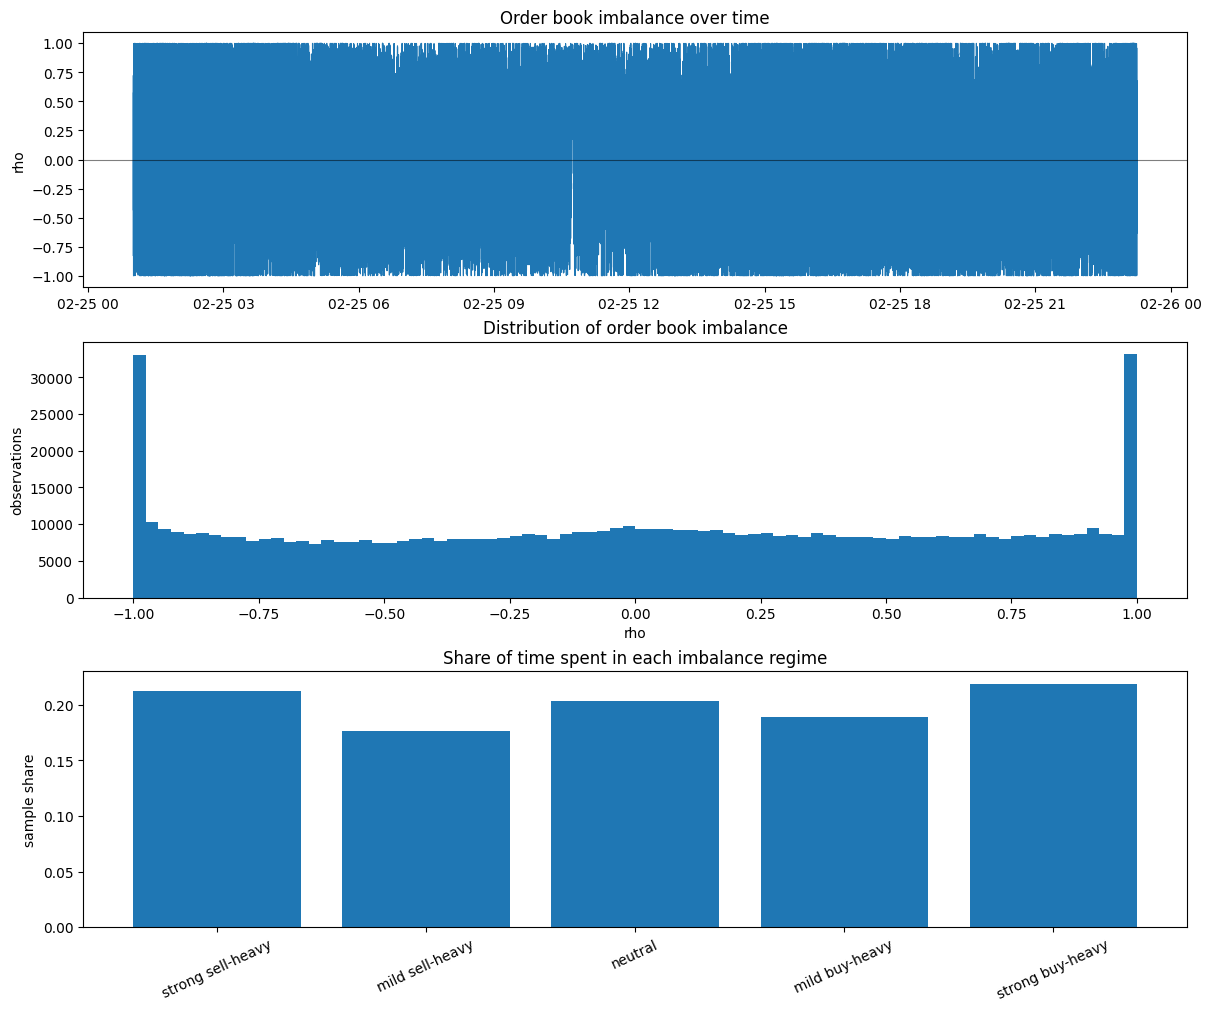

,time_bucket,mean_rho,median_rho,observations
0,01:00,-0.029393,-0.031354,34695
1,02:00,-0.067088,-0.099638,32591
2,03:00,-0.017781,-0.051225,32494
3,04:00,0.094494,0.156881,30321
4,05:00,0.028691,0.034742,31935
5,06:00,0.073308,0.078521,29755
6,07:00,0.040784,0.061438,30571
7,08:00,0.013692,0.040550,31251
8,09:00,-0.031044,-0.030310,29830
9,10:00,0.064979,0.089255,28655


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), constrained_layout=True)

sample = features.dropna(subset=["rho"]).copy()
max_plot_rows = 50_000
if len(sample) > max_plot_rows:
    sample_plot = sample.iloc[:: max(1, len(sample) // max_plot_rows)].copy()
else:
    sample_plot = sample

axes[0].plot(sample_plot["ts"], sample_plot["rho"], linewidth=0.8)
axes[0].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[0].set_title("Order book imbalance over time")
axes[0].set_ylabel("rho")

axes[1].hist(sample["rho"], bins=80)
axes[1].set_title("Distribution of order book imbalance")
axes[1].set_xlabel("rho")
axes[1].set_ylabel("observations")

axes[2].bar(occupancy["Z_label"].astype(str), occupancy["sample_share"])
axes[2].set_title("Share of time spent in each imbalance regime")
axes[2].set_ylabel("sample share")
axes[2].tick_params(axis="x", rotation=25)

plt.show()

tod_summary = (
    features.dropna(subset=["rho", "ts"])
    .assign(time_bucket=lambda x: x["ts"].dt.floor("1h").dt.strftime("%H:%M"))
    .groupby("time_bucket", observed=True)
    .agg(mean_rho=("rho", "mean"), median_rho=("rho", "median"), observations=("rho", "size"))
    .reset_index()
)
display(tod_summary)


## 5. Next-Event Analysis

The paper checks whether imbalance helps predict the side of the next market order. We will estimate:

$$
P(\text{next MO is buy} \mid Z_t = z)
$$

and:

$$
P(\text{next MO is sell} \mid Z_t = z)
$$

Interpretation:

- if buy-heavy states are followed by more buy market orders, imbalance contains directional information about immediate order flow
- if probabilities are close to unconditional baselines, the state may not help with next-event direction

This is descriptive. It does not assume the relationship is causal.

In [6]:
def prepare_trades(trades: pd.DataFrame) -> pd.DataFrame:
    out = trades.copy()
    out["trade_side"] = np.where(out["aggr_sign"] > 0, "buy", np.where(out["aggr_sign"] < 0, "sell", pd.NA))
    out = out[out["trade_side"].isin(["buy", "sell"])].copy()
    return out.sort_values(["source_day", "recv_time_ms", "recv_seq"]).reset_index(drop=True)


def add_next_trade_side(features: pd.DataFrame, trades: pd.DataFrame) -> pd.DataFrame:
    out = features.copy()
    out["next_mo_side"] = pd.NA
    out["next_mo_delay_ms"] = np.nan

    for day, idx in out.groupby("source_day", dropna=False).groups.items():
        day_trades = trades[trades["source_day"] == day].sort_values(["recv_time_ms", "recv_seq"])
        if day_trades.empty:
            continue
        trade_times = day_trades["recv_time_ms"].to_numpy(dtype="float64")
        trade_sides = day_trades["trade_side"].to_numpy(dtype=object)
        row_times = out.loc[idx, "recv_time_ms"].to_numpy(dtype="float64")
        pos = np.searchsorted(trade_times, row_times, side="right")
        valid = pos < len(day_trades)
        valid_idx = np.asarray(idx)[valid]
        out.loc[valid_idx, "next_mo_side"] = trade_sides[pos[valid]]
        out.loc[valid_idx, "next_mo_delay_ms"] = trade_times[pos[valid]] - row_times[valid]
    return out


trades_clean = prepare_trades(trades)
features = add_next_trade_side(features, trades_clean)

next_event_table = (
    features.dropna(subset=["Z", "next_mo_side"])
    .groupby(["Z", "Z_label"], observed=True)["next_mo_side"]
    .value_counts(normalize=True)
    .rename("probability")
    .reset_index()
    .pivot(index=["Z", "Z_label"], columns="next_mo_side", values="probability")
    .fillna(0)
    .reset_index()
    .sort_values("Z")
)

unconditional_next_event = features["next_mo_side"].value_counts(normalize=True).rename("probability")
display(next_event_table)
display(unconditional_next_event)


next_mo_side,Z,Z_label,buy,sell
0,1,strong sell-heavy,0.319227,0.680773
1,2,mild sell-heavy,0.423114,0.576886
2,3,neutral,0.485556,0.514444
3,4,mild buy-heavy,0.551584,0.448416
4,5,strong buy-heavy,0.656189,0.343811


next_mo_side
sell    0.511585
buy     0.488415
Name: probability, dtype: float64

## 6. Market Order Intensity

Intensity measures how many market orders arrive in a recent time window. The main object of interest here is total activity: whether market-order flow generally increased or decreased. We still compute buy and sell components in the code, but only as optional extensions for later analysis.

For a fixed lookback window $W$ ending at time $t$:

$$
\lambda^{raw}_{buy}(t; W) = \#\{\text{buy MOs in } (t-W, t]\}
$$

$$
\lambda^{raw}_{sell}(t; W) = \#\{\text{sell MOs in } (t-W, t]\}
$$

$$
\lambda^{raw}_{total}(t; W) = \lambda^{raw}_{buy}(t; W) + \lambda^{raw}_{sell}(t; W)
$$

Normalized rates divide by the window length in milliseconds:

$$
\lambda^{rate}_{buy}(t; W) = \frac{\lambda^{raw}_{buy}(t; W)}{W_{ms}}
$$

$$
\lambda^{rate}_{sell}(t; W) = \frac{\lambda^{raw}_{sell}(t; W)}{W_{ms}}
$$

$$
\lambda^{rate}_{total}(t; W) = \frac{\lambda^{raw}_{total}(t; W)}{W_{ms}}
$$

Default window definition:

- fixed clock-time lookback window `(t - W, t]`
- `W` measured in milliseconds
- default windows from `LAMBDA_WINDOWS_MS`

Robustness definitions:

- rolling event window: use the last `N` market orders and normalize by elapsed milliseconds
- state-aligned window: use the time from entry into the current imbalance state until now

Plain-language interpretation: intensity tells us whether the market is active or quiet while the book is in a given imbalance state. In this notebook, the default summary focuses on total activity rather than buy/sell decomposition.

In [7]:
def _count_in_window(times: np.ndarray, row_times: np.ndarray, window_ms: int) -> np.ndarray:
    right = np.searchsorted(times, row_times, side="right")
    left = np.searchsorted(times, row_times - window_ms, side="right")
    return right - left


def add_fixed_window_intensity(features: pd.DataFrame, trades: pd.DataFrame, windows_ms: list[int]) -> pd.DataFrame:
    out = features.copy()
    for window_ms in windows_ms:
        for side in ("buy", "sell", "total"):
            out[f"lambda_{side}_raw_{window_ms}ms"] = 0
            out[f"lambda_{side}_rate_{window_ms}ms"] = 0.0

    for day, idx in out.groupby("source_day", dropna=False).groups.items():
        day_trades = trades[trades["source_day"] == day]
        row_times = out.loc[idx, "recv_time_ms"].to_numpy(dtype="float64")
        trade_times = day_trades["recv_time_ms"].to_numpy(dtype="float64")
        buy_times = day_trades.loc[day_trades["trade_side"] == "buy", "recv_time_ms"].to_numpy(dtype="float64")
        sell_times = day_trades.loc[day_trades["trade_side"] == "sell", "recv_time_ms"].to_numpy(dtype="float64")
        for window_ms in windows_ms:
            buy_counts = _count_in_window(buy_times, row_times, window_ms)
            sell_counts = _count_in_window(sell_times, row_times, window_ms)
            total_counts = _count_in_window(trade_times, row_times, window_ms)
            for side, counts in (("buy", buy_counts), ("sell", sell_counts), ("total", total_counts)):
                out.loc[idx, f"lambda_{side}_raw_{window_ms}ms"] = counts
                out.loc[idx, f"lambda_{side}_rate_{window_ms}ms"] = counts / window_ms
    return out


def add_event_window_intensity(features: pd.DataFrame, trades: pd.DataFrame, event_windows: list[int]) -> pd.DataFrame:
    out = features.copy()
    for n_events in event_windows:
        for side in ("buy", "sell", "total"):
            out[f"event_lambda_{side}_raw_{n_events}mo"] = 0
            out[f"event_lambda_{side}_rate_{n_events}mo"] = np.nan

    for day, idx in out.groupby("source_day", dropna=False).groups.items():
        day_trades = trades[trades["source_day"] == day].sort_values(["recv_time_ms", "recv_seq"])
        if day_trades.empty:
            continue
        trade_times = day_trades["recv_time_ms"].to_numpy(dtype="float64")
        is_buy = (day_trades["trade_side"].to_numpy(dtype=object) == "buy").astype(int)
        is_sell = (day_trades["trade_side"].to_numpy(dtype=object) == "sell").astype(int)
        cum_buy = np.r_[0, np.cumsum(is_buy)]
        cum_sell = np.r_[0, np.cumsum(is_sell)]
        row_times = out.loc[idx, "recv_time_ms"].to_numpy(dtype="float64")
        end_pos = np.searchsorted(trade_times, row_times, side="right")
        for n_events in event_windows:
            start_pos = np.maximum(0, end_pos - n_events)
            buy_counts = cum_buy[end_pos] - cum_buy[start_pos]
            sell_counts = cum_sell[end_pos] - cum_sell[start_pos]
            total_counts = end_pos - start_pos
            elapsed_ms = np.where(total_counts > 0, row_times - trade_times[start_pos], np.nan)
            elapsed_ms = np.where(elapsed_ms > 0, elapsed_ms, np.nan)
            for side, counts in (("buy", buy_counts), ("sell", sell_counts), ("total", total_counts)):
                out.loc[idx, f"event_lambda_{side}_raw_{n_events}mo"] = counts
                out.loc[idx, f"event_lambda_{side}_rate_{n_events}mo"] = counts / elapsed_ms
    return out


def add_state_aligned_intensity(features: pd.DataFrame, trades: pd.DataFrame) -> pd.DataFrame:
    out = features.copy()
    out["state_run_id"] = pd.NA
    out["state_elapsed_ms"] = np.nan
    for side in ("buy", "sell", "total"):
        out[f"state_lambda_{side}_raw"] = 0
        out[f"state_lambda_{side}_rate"] = np.nan

    group_cols = ["source_day", "epoch_id", "segment_index"]
    for _, idx in out.groupby(group_cols, dropna=False).groups.items():
        idx = np.asarray(idx)
        z = out.loc[idx, "Z"]
        run_id = z.ne(z.shift()).cumsum().to_numpy()
        out.loc[idx, "state_run_id"] = run_id
        run_start = out.loc[idx].groupby(run_id, observed=True)["recv_time_ms"].transform("first")
        out.loc[idx, "state_elapsed_ms"] = out.loc[idx, "recv_time_ms"].to_numpy(dtype="float64") - run_start.to_numpy(dtype="float64")

    for day, idx in out.groupby("source_day", dropna=False).groups.items():
        day_trades = trades[trades["source_day"] == day]
        row_times = out.loc[idx, "recv_time_ms"].to_numpy(dtype="float64")
        start_times = row_times - out.loc[idx, "state_elapsed_ms"].fillna(0).to_numpy(dtype="float64")
        for side_name, side_filter in (("buy", "buy"), ("sell", "sell"), ("total", None)):
            if side_filter is None:
                side_times = day_trades["recv_time_ms"].to_numpy(dtype="float64")
            else:
                side_times = day_trades.loc[day_trades["trade_side"] == side_filter, "recv_time_ms"].to_numpy(dtype="float64")
            right = np.searchsorted(side_times, row_times, side="right")
            left = np.searchsorted(side_times, start_times, side="right")
            counts = right - left
            elapsed = out.loc[idx, "state_elapsed_ms"].to_numpy(dtype="float64")
            out.loc[idx, f"state_lambda_{side_name}_raw"] = counts
            out.loc[idx, f"state_lambda_{side_name}_rate"] = counts / np.where(elapsed > 0, elapsed, np.nan)
    return out


features = add_fixed_window_intensity(features, trades_clean, LAMBDA_WINDOWS_MS)
features = add_event_window_intensity(features, trades_clean, EVENT_WINDOWS)
features = add_state_aligned_intensity(features, trades_clean)

default_lambda_window = LAMBDA_WINDOWS_MS[-1]
# Main summary: total market-order activity only.
lambda_summary_total = (
    features.dropna(subset=["Z"])
    .groupby(["Z", "Z_label"], observed=True)[
        [
            f"lambda_total_raw_{default_lambda_window}ms",
            f"lambda_total_rate_{default_lambda_window}ms",
            "state_lambda_total_rate",
        ]
    ]
    .mean()
    .reset_index()
    .sort_values("Z")
)

# Optional follow-up: the dataframe still contains buy/sell activity columns if we want them later.
display(lambda_summary_total)


,Z,Z_label,lambda_total_raw_3000ms,lambda_total_rate_3000ms,state_lambda_total_rate
0,1,strong sell-heavy,38.872769,0.012958,0.015644
1,2,mild sell-heavy,33.415783,0.011139,0.002151
2,3,neutral,30.769477,0.010256,0.001647
3,4,mild buy-heavy,31.723871,0.010575,0.002375
4,5,strong buy-heavy,34.373564,0.011458,0.013324


## 7. Imbalance Transition Probabilities

The transition matrix describes how imbalance states move over time.

For states $i$ and $j$:

$$
P_{ij} = P(Z_{t+1} = j \mid Z_t = i)
$$

We estimate this with observed transitions:

$$
\hat{P}_{ij} = \frac{\#\{Z_t = i, Z_{t+1} = j\}}{\#\{Z_t = i\}}
$$

What to look for:

- large diagonal values mean states are persistent
- mass moving toward the middle means mean reversion toward neutral
- jumps from extreme sell-heavy to extreme buy-heavy mean fast regime switching

We should compare this by symbol, time of day, and spread state if the data supports it.

to_Z,1,2,3,4,5
from_Z,,,,,
1,0.826,0.113,0.034,0.017,0.011
2,0.137,0.697,0.118,0.030,0.019
3,0.041,0.101,0.715,0.105,0.038
4,0.019,0.027,0.117,0.707,0.129
5,0.010,0.015,0.032,0.110,0.833


to_Z,1,2,3,4,5
from_Z,,,,,
1,0.832,0.109,0.033,0.016,0.010
2,0.129,0.712,0.113,0.028,0.018
3,0.039,0.097,0.729,0.100,0.035
4,0.018,0.025,0.112,0.723,0.122
5,0.010,0.014,0.030,0.106,0.840


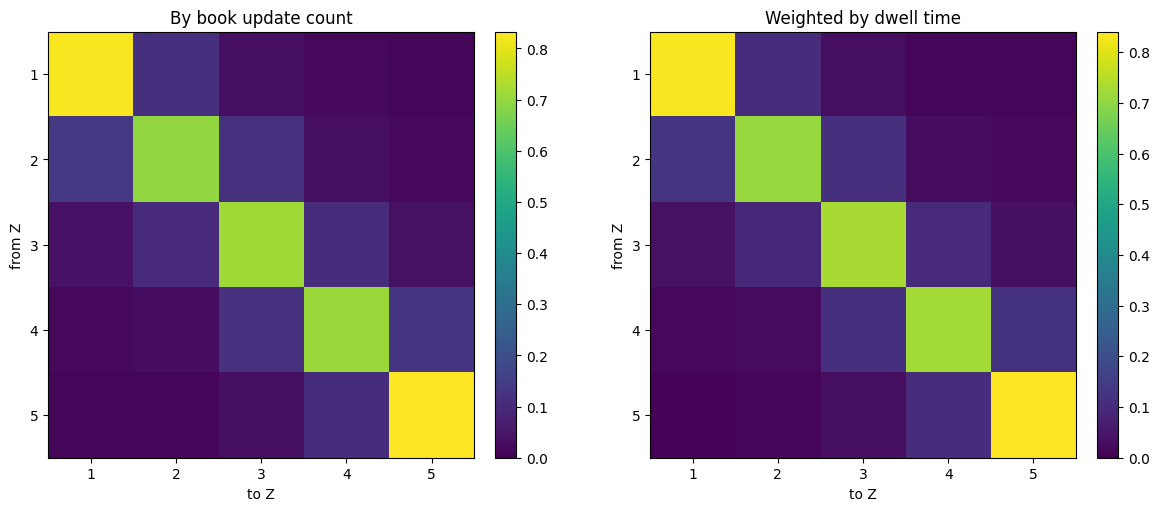

In [8]:
def build_transition_tables(features: pd.DataFrame, *, n_regimes: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    group_cols = ["source_day", "epoch_id", "segment_index"]
    for _, part in features.dropna(subset=["Z"]).groupby(group_cols, dropna=False):
        part = part.sort_values(["recv_time_ms", "recv_seq"])
        current_z = part["Z"].astype("int64")
        next_z = current_z.shift(-1)
        valid = next_z.notna()
        if valid.any():
            rows.append(
                pd.DataFrame(
                    {
                        "from_Z": current_z[valid].to_numpy(),
                        "to_Z": next_z[valid].astype("int64").to_numpy(),
                        "dt_ms": part.loc[valid, "dt_ms"].to_numpy(dtype="float64"),
                    }
                )
            )
    if not rows:
        empty = pd.DataFrame(index=range(1, n_regimes + 1), columns=range(1, n_regimes + 1), dtype="float64")
        return empty, empty

    transitions = pd.concat(rows, ignore_index=True)
    count_matrix = pd.crosstab(transitions["from_Z"], transitions["to_Z"])
    count_matrix = count_matrix.reindex(index=range(1, n_regimes + 1), columns=range(1, n_regimes + 1), fill_value=0)
    count_prob = count_matrix.div(count_matrix.sum(axis=1).replace(0, np.nan), axis=0)

    time_matrix = transitions.pivot_table(index="from_Z", columns="to_Z", values="dt_ms", aggfunc="sum", fill_value=0)
    time_matrix = time_matrix.reindex(index=range(1, n_regimes + 1), columns=range(1, n_regimes + 1), fill_value=0)
    time_prob = time_matrix.div(time_matrix.sum(axis=1).replace(0, np.nan), axis=0)
    return count_prob, time_prob


transition_prob_by_event, transition_prob_by_time = build_transition_tables(features, n_regimes=N_REGIMES)

display(transition_prob_by_event.style.format("{:.3f}").set_caption("Transition probabilities by book update count"))
display(transition_prob_by_time.style.format("{:.3f}").set_caption("Transition probabilities weighted by dwell time"))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, matrix, title in (
    (axes[0], transition_prob_by_event, "By book update count"),
    (axes[1], transition_prob_by_time, "Weighted by dwell time"),
):
    image = ax.imshow(matrix.to_numpy(dtype="float64"), vmin=0, vmax=np.nanmax(matrix.to_numpy(dtype="float64")))
    ax.set_title(title)
    ax.set_xlabel("to Z")
    ax.set_ylabel("from Z")
    ax.set_xticks(range(N_REGIMES), labels=range(1, N_REGIMES + 1))
    ax.set_yticks(range(N_REGIMES), labels=range(1, N_REGIMES + 1))
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.show()


## 8. Price Impact Conditioned on Trade Direction

This section asks whether the price response after a market order depends on both the trade side and the imbalance state.

For a horizon $h$ in milliseconds, define forward midprice change:

$$
\Delta P_h(t) = M_{t+h} - M_t
$$

where $M_t$ is the midprice at time $t$.

Unit: `delta_mid` is measured in the same price unit as the instrument's order book prices. For `BTCUSDC`, a value of `+1.00` means the midprice is 1 USDC higher per BTC at the forward horizon; `-1.00` means it is 1 USDC lower per BTC. It is not a return, basis-point move, or tick count unless we explicitly normalize it later.

Core quantities:

$$
E[\Delta P_h \mid \text{buy MO}, Z_t = z]
$$

$$
E[\Delta P_h \mid \text{sell MO}, Z_t = z]
$$

Plain-language interpretation:

- compare the average future price move after buy market orders in each imbalance state
- compare the same statistic after sell market orders
- check whether a buy market order has larger impact when the book is already buy-heavy
- check whether the effect decays as $h$ increases

Planned summaries:

- mean and median $\Delta P_h$
- quantiles of $\Delta P_h$
- probability that $\Delta P_h > 0$
- heatmaps with rows = imbalance states and columns = trade side

In [9]:
def add_current_book_state_to_trades(features: pd.DataFrame, trades: pd.DataFrame) -> pd.DataFrame:
    rows = []
    lambda_state_cols = [col for col in features.columns if col.startswith(("lambda_", "event_lambda_", "state_lambda_"))]
    state_cols = ["source_day", "recv_time_ms", "recv_seq", "epoch_id", "segment_index", "mid", "spread", "rho", "Z", "Z_label"] + lambda_state_cols
    for day, day_trades in trades.groupby("source_day", dropna=False):
        day_book = features.loc[features["source_day"] == day, state_cols].sort_values(["recv_time_ms", "recv_seq"]).reset_index(drop=True)
        day_trades = day_trades.sort_values(["recv_time_ms", "recv_seq"]).reset_index(drop=True)
        if day_book.empty or day_trades.empty:
            continue
        book_times = day_book["recv_time_ms"].to_numpy(dtype="float64")
        trade_times = day_trades["recv_time_ms"].to_numpy(dtype="float64")
        pos = np.searchsorted(book_times, trade_times, side="right") - 1
        valid = pos >= 0
        if not valid.any():
            continue
        matched = day_book.iloc[pos[valid]].reset_index(drop=True).add_prefix("book_")
        trade_part = day_trades.loc[valid].reset_index(drop=True)
        rows.append(pd.concat([trade_part, matched], axis=1))
    if not rows:
        return pd.DataFrame()
    out = pd.concat(rows, ignore_index=True)
    out["Z"] = out["book_Z"].astype("Int64")
    out["Z_label"] = out["book_Z_label"].astype("string")
    out["rho"] = out["book_rho"]
    out["mid_at_event"] = out["book_mid"]
    out["epoch_id"] = out["book_epoch_id"]
    out["segment_index"] = out["book_segment_index"]
    for col in lambda_state_cols:
        out[col] = out[f"book_{col}"]
    return out


def add_forward_mid_changes(events: pd.DataFrame, book: pd.DataFrame, horizons_ms: list[int], *, time_col: str = "recv_time_ms") -> pd.DataFrame:
    out = events.copy()
    for horizon_ms in horizons_ms:
        out[f"delta_mid_{horizon_ms}ms"] = np.nan

    group_cols = ["source_day", "epoch_id", "segment_index"]
    for keys, event_idx in out.groupby(group_cols, dropna=False).groups.items():
        source_day, epoch_id, segment_index = keys
        book_part = book[
            (book["source_day"] == source_day)
            & (book["epoch_id"] == epoch_id)
            & (book["segment_index"] == segment_index)
        ].sort_values(["recv_time_ms", "recv_seq"])
        if book_part.empty:
            continue
        book_times = book_part["recv_time_ms"].to_numpy(dtype="float64")
        book_mid = book_part["mid"].to_numpy(dtype="float64")
        event_times = out.loc[event_idx, time_col].to_numpy(dtype="float64")
        start_mid = out.loc[event_idx, "mid_at_event"].to_numpy(dtype="float64") if "mid_at_event" in out.columns else out.loc[event_idx, "mid"].to_numpy(dtype="float64")
        for horizon_ms in horizons_ms:
            target_times = event_times + horizon_ms
            pos = np.searchsorted(book_times, target_times, side="left")
            valid = pos < len(book_part)
            target_mid = np.full(len(event_idx), np.nan)
            target_mid[valid] = book_mid[pos[valid]]
            out.loc[np.asarray(event_idx), f"delta_mid_{horizon_ms}ms"] = target_mid - start_mid
    return out


trade_states = add_current_book_state_to_trades(features, trades_clean)
trade_states = add_forward_mid_changes(trade_states, features, IMPACT_HORIZONS_MS, time_col="recv_time_ms")

conditioned_impact_rows = []
for horizon_ms in IMPACT_HORIZONS_MS:
    col = f"delta_mid_{horizon_ms}ms"
    grouped = (
        trade_states.dropna(subset=["Z", "trade_side", col])
        .groupby(["Z", "Z_label", "trade_side"], observed=True)[col]
        .agg(
            observations="size",
            mean="mean",
            median="median",
            p05=lambda x: x.quantile(0.05),
            p95=lambda x: x.quantile(0.95),
            prob_positive=lambda x: (x > 0).mean(),
        )
        .reset_index()
    )
    grouped["horizon_ms"] = horizon_ms
    conditioned_impact_rows.append(grouped)

conditioned_impact = pd.concat(conditioned_impact_rows, ignore_index=True) if conditioned_impact_rows else pd.DataFrame()
default_impact_horizon = 100
display(conditioned_impact[conditioned_impact["horizon_ms"] == default_impact_horizon].sort_values(["Z", "trade_side"]))

if not conditioned_impact.empty:
    heatmap_data = conditioned_impact[conditioned_impact["horizon_ms"] == default_impact_horizon].pivot(index="Z_label", columns="trade_side", values="mean")
    display(heatmap_data)


,Z,Z_label,trade_side,observations,mean,median,p05,p95,prob_positive,horizon_ms
20,1,strong sell-heavy,buy,28734,5.045106,0.00,-11.72,32.195,0.488829,100
21,1,strong sell-heavy,sell,265285,-6.709260,-5.17,-18.57,0.000,0.019715,100
22,2,mild sell-heavy,buy,27938,8.419283,5.03,-6.69,38.790,0.647720,100
23,2,mild sell-heavy,sell,62580,-6.915580,-5.24,-23.03,0.000,0.035682,100
24,3,neutral,buy,43319,10.097212,6.38,-2.20,39.280,0.748147,100
25,3,neutral,sell,43390,-7.067991,-5.01,-26.78,1.890,0.062872,100
26,4,mild buy-heavy,buy,66090,8.471144,6.01,0.00,27.070,0.831608,100
27,4,mild buy-heavy,sell,29623,-6.324512,-3.44,-26.67,5.710,0.110995,100
28,5,strong buy-heavy,buy,248104,8.178224,5.70,0.00,26.545,0.927655,100
29,5,strong buy-heavy,sell,30165,-3.789905,0.00,-30.26,13.050,0.285563,100


trade_side,buy,sell
Z_label,,
mild buy-heavy,8.471144,-6.324512
mild sell-heavy,8.419283,-6.915580
neutral,10.097212,-7.067991
strong buy-heavy,8.178224,-3.789905
strong sell-heavy,5.045106,-6.709260


## 9. Short-Horizon Price Impact

This section measures forward midprice changes by imbalance state, without necessarily conditioning on trade side.

For each horizon $h$ in `IMPACT_HORIZONS_MS`, compute:

$$
\Delta P_h(t) = M_{t+h} - M_t
$$

Then summarize:

$$
E[\Delta P_h \mid Z_t = z]
$$

Unit: the mean is the average absolute midprice change in price units. For `BTCUSDC`, `mean = 0.25` means the average forward midprice change is `+0.25` USDC per BTC over that horizon. Negative values mean the average forward midprice moved down. This is intentionally not normalized yet; if we want comparability across symbols or price levels, we should add bps or tick-normalized versions later.

The current horizon grid is:

- `10ms`
- `50ms`
- `100ms`
- `250ms`
- `500ms`
- `1000ms`
- `2000ms`
- `3000ms`

Plain-language interpretation: this asks whether imbalance states are followed by different price movements over the next few milliseconds to three seconds.

,Z,Z_label,observations,mean,median,p05,p95,prob_positive,horizon_ms
0,1,strong sell-heavy,158145,-0.656781,0.0,-5.420,0.000,0.008473,10
1,2,mild sell-heavy,126892,-0.127511,0.0,0.000,0.000,0.015746,10
2,3,neutral,144671,0.014107,0.0,0.000,0.000,0.025216,10
3,4,mild buy-heavy,134285,0.161235,0.0,0.000,0.000,0.049283,10
4,5,strong buy-heavy,160757,0.626091,0.0,0.000,5.311,0.151801,10
5,1,strong sell-heavy,158145,-0.656708,0.0,-5.420,0.000,0.008480,50
6,2,mild sell-heavy,126892,-0.127513,0.0,0.000,0.000,0.015754,50
7,3,neutral,144671,0.014062,0.0,0.000,0.000,0.025216,50
8,4,mild buy-heavy,134285,0.161222,0.0,0.000,0.000,0.049283,50
9,5,strong buy-heavy,160757,0.626053,0.0,0.000,5.316,0.151801,50


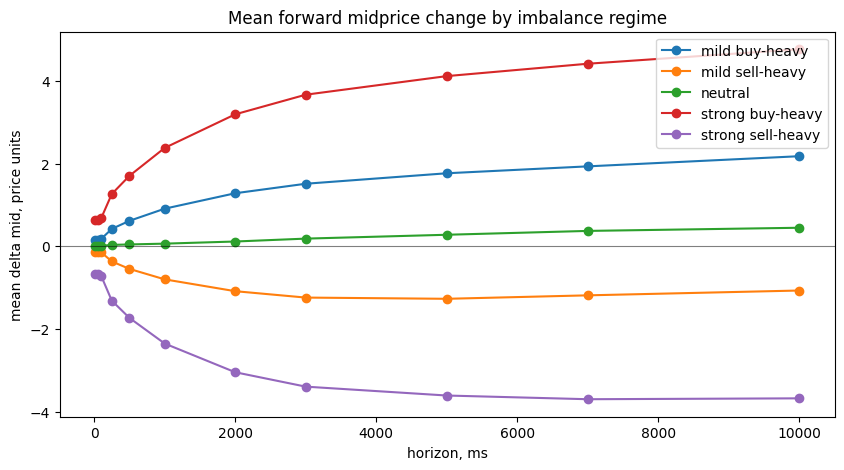

In [10]:
features = add_forward_mid_changes(features, features, IMPACT_HORIZONS_MS, time_col="recv_time_ms")

impact_rows = []
for horizon_ms in IMPACT_HORIZONS_MS:
    col = f"delta_mid_{horizon_ms}ms"
    summary = (
        features.dropna(subset=["Z", col])
        .groupby(["Z", "Z_label"], observed=True)[col]
        .agg(
            observations="size",
            mean="mean",
            median="median",
            p05=lambda x: x.quantile(0.05),
            p95=lambda x: x.quantile(0.95),
            prob_positive=lambda x: (x > 0).mean(),
        )
        .reset_index()
    )
    summary["horizon_ms"] = horizon_ms
    impact_rows.append(summary)

impact_by_state = pd.concat(impact_rows, ignore_index=True) if impact_rows else pd.DataFrame()
display(impact_by_state.head(20))

fig, ax = plt.subplots(figsize=(10, 5))
for label, part in impact_by_state.groupby("Z_label", observed=True):
    part = part.sort_values("horizon_ms")
    ax.plot(part["horizon_ms"], part["mean"], marker="o", label=str(label))
ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
ax.set_title("Mean forward midprice change by imbalance regime")
ax.set_xlabel("horizon, ms")
ax.set_ylabel("mean delta mid, price units")
ax.legend()
plt.show()


## 10. Joint Conditioning on Activity and Imbalance

This section combines total market-order activity with the imbalance state.

We bucket the total market-order rate over the default lookback window into three relative activity regimes:

- `low`
- `mid`
- `high`

Here the bucket is defined relative to the sample, not by an absolute threshold.

Then we ask:

$$
E[\Delta P_h \mid Z_t = z, \lambda_{total}(t; W) \in \text{bucket}]
$$

For readability, we also collapse the imbalance states into two families:

- `heavy` = strongly buy-heavy or strongly sell-heavy
- `mid` = mildly buy-heavy or mildly sell-heavy

The slice I care about most is `high` activity together with `heavy` imbalance.


In [11]:
def add_activity_bucket(frame: pd.DataFrame, source_col: str, bucket_col: str, *, labels: list[str]) -> pd.DataFrame:
    out = frame.copy()
    out[bucket_col] = pd.Series(pd.NA, index=out.index, dtype="string")
    valid = out[source_col].notna()
    if not valid.any():
        return out

    ranks = out.loc[valid, source_col].rank(method="first")
    out.loc[valid, bucket_col] = pd.cut(ranks, bins=len(labels), labels=labels, include_lowest=True).astype("string")
    return out


joint_frame = features.copy()
lambda_total_col = f"lambda_total_rate_{default_lambda_window}ms"
joint_frame["time_bucket"] = joint_frame["ts"].dt.floor("1h").dt.strftime("%H:%M")
z_label = joint_frame["Z_label"].astype("string")
joint_frame["imbalance_family"] = np.select(
    [
        z_label.str.contains("strong buy-heavy", na=False) | z_label.str.contains("strong sell-heavy", na=False),
        z_label.str.contains("mild buy-heavy", na=False) | z_label.str.contains("mild sell-heavy", na=False),
    ],
    ["heavy", "mid"],
    default=pd.NA,
)
joint_frame = add_activity_bucket(joint_frame, lambda_total_col, "lambda_total_bucket", labels=["low", "mid", "high"])

joint_state_rows = []
joint_family_rows = []
for horizon_ms in IMPACT_HORIZONS_MS:
    target_col = f"delta_mid_{horizon_ms}ms"
    if target_col not in joint_frame.columns:
        continue

    state_summary = (
        joint_frame.dropna(subset=["Z", "Z_label", "imbalance_family", "lambda_total_bucket", target_col])
        .groupby(["imbalance_family", "Z", "Z_label", "lambda_total_bucket"], observed=True)[target_col]
        .agg(
            observations="size",
            mean="mean",
            median="median",
            p05=lambda x: x.quantile(0.05),
            p95=lambda x: x.quantile(0.95),
            prob_positive=lambda x: (x > 0).mean(),
        )
        .reset_index()
    )
    state_summary["horizon_ms"] = horizon_ms
    joint_state_rows.append(state_summary)

    family_summary = (
        joint_frame.dropna(subset=["imbalance_family", "lambda_total_bucket", target_col])
        .groupby(["imbalance_family", "lambda_total_bucket"], observed=True)[target_col]
        .agg(
            observations="size",
            mean="mean",
            median="median",
            p05=lambda x: x.quantile(0.05),
            p95=lambda x: x.quantile(0.95),
            prob_positive=lambda x: (x > 0).mean(),
        )
        .reset_index()
    )
    family_summary["horizon_ms"] = horizon_ms
    joint_family_rows.append(family_summary)

joint_state_columns = ["imbalance_family", "Z", "Z_label", "lambda_total_bucket", "observations", "mean", "median", "p05", "p95", "prob_positive", "horizon_ms"]
joint_family_columns = ["imbalance_family", "lambda_total_bucket", "observations", "mean", "median", "p05", "p95", "prob_positive", "horizon_ms"]
joint_impact_by_state = pd.concat(joint_state_rows, ignore_index=True) if joint_state_rows else pd.DataFrame(columns=joint_state_columns)
joint_impact_by_family = pd.concat(joint_family_rows, ignore_index=True) if joint_family_rows else pd.DataFrame(columns=joint_family_columns)

display(joint_impact_by_family.sort_values(["horizon_ms", "imbalance_family", "lambda_total_bucket"]))

high_lambda_high_imbalance = joint_impact_by_state[
    (joint_impact_by_state["imbalance_family"] == "heavy")
    & (joint_impact_by_state["lambda_total_bucket"] == "high")
].sort_values(["horizon_ms", "Z", "Z_label"])
display(high_lambda_high_imbalance)


,imbalance_family,lambda_total_bucket,observations,mean,median,p05,p95,prob_positive,horizon_ms
0,heavy,high,114939,-0.031169,0.0,-4.930,4.4600,0.116523,10
1,heavy,low,91636,0.009452,0.0,0.000,0.0000,0.040028,10
2,heavy,mid,112327,-0.004468,0.0,-2.430,2.3300,0.077292,10
3,mid,high,83245,0.034598,0.0,-0.670,1.0500,0.059727,10
4,mid,low,94063,0.005562,0.0,0.000,0.0000,0.012768,10
...,...,...,...,...,...,...,...,...,...
61,heavy,low,91608,0.573019,0.0,-29.320,31.4300,0.463562,10000
62,heavy,mid,112321,0.619566,0.0,-35.230,37.8000,0.478352,10000
63,mid,high,83245,0.776181,0.0,-47.614,48.8160,0.480233,10000
64,mid,low,94046,0.327446,0.0,-26.910,28.9875,0.421506,10000


,imbalance_family,Z,Z_label,lambda_total_bucket,observations,mean,median,p05,p95,prob_positive,horizon_ms
0,heavy,1,strong sell-heavy,high,62237,-0.931385,0.00,-6.6500,0.0000,0.014782,10
3,heavy,5,strong buy-heavy,high,52702,1.031918,0.00,0.0000,6.9000,0.236670,10
12,heavy,1,strong sell-heavy,high,62237,-0.931199,0.00,-6.6500,0.0000,0.014798,50
15,heavy,5,strong buy-heavy,high,52702,1.031839,0.00,0.0000,6.9000,0.236670,50
24,heavy,1,strong sell-heavy,high,62237,-1.016250,0.00,-6.9000,0.0000,0.019169,100
27,heavy,5,strong buy-heavy,high,52702,1.121932,0.00,0.0000,7.3800,0.250370,100
36,heavy,1,strong sell-heavy,high,62237,-1.719592,0.00,-10.2100,0.0900,0.051207,250
39,heavy,5,strong buy-heavy,high,52702,1.911848,0.00,-0.9300,11.0295,0.370783,250
48,heavy,1,strong sell-heavy,high,62237,-2.151729,0.00,-12.9000,5.2000,0.088388,500
51,heavy,5,strong buy-heavy,high,52702,2.431107,0.00,-5.3800,13.6900,0.443190,500


## 11. Correlation Analysis

This section keeps the analysis descriptive. Instead of fitting a classifier, compute simple correlations between current signals and future price changes.

Unconditional examples:

$$
\text{corr}(\rho_t, \Delta P_h)
$$

$$
\text{corr}(\lambda_{total}(t; W), \Delta P_h)
$$

Conditioned correlations:

- compute correlations within each imbalance state $Z_t = z$
- compare raw count intensity against normalized rate intensity for total activity
- keep directional buy/sell intensity as an optional extension, not the default focus
- compute correlations after collapsing strong buy-heavy and strong sell-heavy into one `heavy` family
- compute the same kind of split after collapsing mild buy-heavy and mild sell-heavy into one `mid` family
- compute correlations within time-of-day buckets
- report both Pearson and Spearman correlation

Plain-language interpretation: correlation is not a trading model. It is a compact way to check whether the signal and future price move together.

In [ ]:
def _safe_corr(left: pd.Series, right: pd.Series) -> float:
    pair = pd.concat([left, right], axis=1).dropna()
    if len(pair) < 3:
        return np.nan
    if pair.iloc[:, 0].nunique() < 2 or pair.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(pair.iloc[:, 0].corr(pair.iloc[:, 1]))


def _safe_spearman(left: pd.Series, right: pd.Series) -> float:
    pair = pd.concat([left, right], axis=1).dropna()
    if len(pair) < 3:
        return np.nan
    if pair.iloc[:, 0].nunique() < 2 or pair.iloc[:, 1].nunique() < 2:
        return np.nan
    return float(pair.iloc[:, 0].corr(pair.iloc[:, 1], method="spearman"))


def build_correlation_table(
    frame: pd.DataFrame,
    *,
    signal_cols: list[str],
    horizons_ms: list[int],
    condition_cols: list[str] | None = None,
) -> pd.DataFrame:
    condition_cols = condition_cols or []
    rows = []

    if condition_cols:
        groups = frame.groupby(condition_cols, observed=True, dropna=False)
    else:
        groups = [((), frame)]

    for key, part in groups:
        if condition_cols and not isinstance(key, tuple):
            key = (key,)
        condition_values = dict(zip(condition_cols, key)) if condition_cols else {}
        for horizon_ms in horizons_ms:
            target_col = f"delta_mid_{horizon_ms}ms"
            if target_col not in part.columns:
                continue
            for signal_col in signal_cols:
                if signal_col not in part.columns:
                    continue
                pair = part[[signal_col, target_col]].dropna()
                rows.append(
                    {
                        **condition_values,
                        "signal": signal_col,
                        "target": target_col,
                        "horizon_ms": horizon_ms,
                        "observations": len(pair),
                        "pearson_corr": _safe_corr(part[signal_col], part[target_col]),
                        "spearman_corr": _safe_spearman(part[signal_col], part[target_col]),
                    }
                )
    return pd.DataFrame(rows)


default_window = LAMBDA_WINDOWS_MS[-1]
correlation_signals = [
    "rho",
    f"lambda_total_raw_{default_window}ms",
    f"lambda_total_rate_{default_window}ms",
]

features_for_corr = features.copy()
features_for_corr["time_bucket"] = features_for_corr["ts"].dt.floor("1h").dt.strftime("%H:%M")
z_label = features_for_corr["Z_label"].astype("string")
features_for_corr["imbalance_family"] = np.select(
    [
        z_label.str.contains("strong buy-heavy", na=False) | z_label.str.contains("strong sell-heavy", na=False),
        z_label.str.contains("mild buy-heavy", na=False) | z_label.str.contains("mild sell-heavy", na=False),
    ],
    ["heavy", "mid"],
    default=pd.NA,
)
features_for_corr_family = features_for_corr.dropna(subset=["imbalance_family"]).copy()

corr_unconditional = build_correlation_table(
    features_for_corr,
    signal_cols=correlation_signals,
    horizons_ms=IMPACT_HORIZONS_MS,
)
corr_by_state = build_correlation_table(
    features_for_corr,
    signal_cols=correlation_signals,
    horizons_ms=IMPACT_HORIZONS_MS,
    condition_cols=["Z", "Z_label"],
)
corr_by_time = build_correlation_table(
    features_for_corr,
    signal_cols=correlation_signals,
    horizons_ms=IMPACT_HORIZONS_MS,
    condition_cols=["time_bucket"],
)
corr_by_trade_side = build_correlation_table(
    trade_states,
    signal_cols=correlation_signals,
    horizons_ms=IMPACT_HORIZONS_MS,
    condition_cols=["trade_side"],
)
corr_by_imbalance_family = build_correlation_table(
    features_for_corr_family,
    signal_cols=correlation_signals,
    horizons_ms=IMPACT_HORIZONS_MS,
    condition_cols=["imbalance_family"],
)
display(corr_unconditional.sort_values(["horizon_ms", "signal"]))
display(corr_by_state.sort_values(["horizon_ms", "Z", "signal"]).head(40))
display(corr_by_trade_side.sort_values(["horizon_ms", "trade_side", "signal"]).head(40))
display(corr_by_imbalance_family.sort_values(["horizon_ms", "imbalance_family", "signal"]).head(40))


## 12. Summary

End the notebook with a short written summary:

- which imbalance states are common or rare
- whether imbalance states persist or revert quickly
- whether market-order intensity changes by state
- whether forward price changes differ by state
- whether high market-order activity together with heavy imbalance behaves differently from the rest of the sample
- whether conditioned correlations are meaningfully different from unconditional correlations
- which parts need more data, better labels, or robustness checks

The next notebook should only add modeling or execution logic if this descriptive pass shows a stable relationship.

In [ ]:
family_df = corr_by_imbalance_family.sort_values(["horizon_ms", "imbalance_family", "signal"])

In [ ]:
#family_df

In [ ]:
family_df.loc[family_df["horizon_ms"]==2000]